1. Setup và Load Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from windrose import WindroseAxes # Thư viện vẽ Pollution Rose

# ==========================================
# 0. THIẾT LẬP GIAO DIỆN CHUNG
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 1. LOAD DỮ LIỆU & TIỀN XỬ LÝ NHANH
# ==========================================
df = pd.read_csv('../data/processed/hcmc_merged_cleaned.csv')
df['datetime_local'] = pd.to_datetime(df['datetime_local'])
if df['datetime_local'].dt.tz is not None:
    df['datetime_local'] = df['datetime_local'].dt.tz_localize(None)
df.set_index('datetime_local', inplace=True)

# BƯỚC BỔ SUNG: KIỂM TRA TRÙNG LẶP BIẾN (OpenAQ vs OpenMeteo)
# ==========================================
print("\n--- Kiểm tra tương quan các biến trùng lặp ---")
if set(['temperature', 'temperature_2m', 'relativehumidity', 'relative_humidity_2m']).issubset(df.columns):
    temp_corr = df['temperature'].corr(df['temperature_2m'])
    humid_corr = df['relativehumidity'].corr(df['relative_humidity_2m'])
    print(f"Độ tương quan Nhiệt độ (OpenAQ vs OpenMeteo): {temp_corr:.4f}")
    print(f"Độ tương quan Độ ẩm (OpenAQ vs OpenMeteo): {humid_corr:.4f}")
    if temp_corr > 0.95:
        print("Nhiệt độ 2 nguồn khớp nhau > 95%. Nên cân nhắc drop 1 cột để tránh đa cộng tuyến.")


--- Kiểm tra tương quan các biến trùng lặp ---
Độ tương quan Nhiệt độ (OpenAQ vs OpenMeteo): 0.7577
Độ tương quan Độ ẩm (OpenAQ vs OpenMeteo): 0.7781


2. Univariate EDA (Phân tích đơn biến)

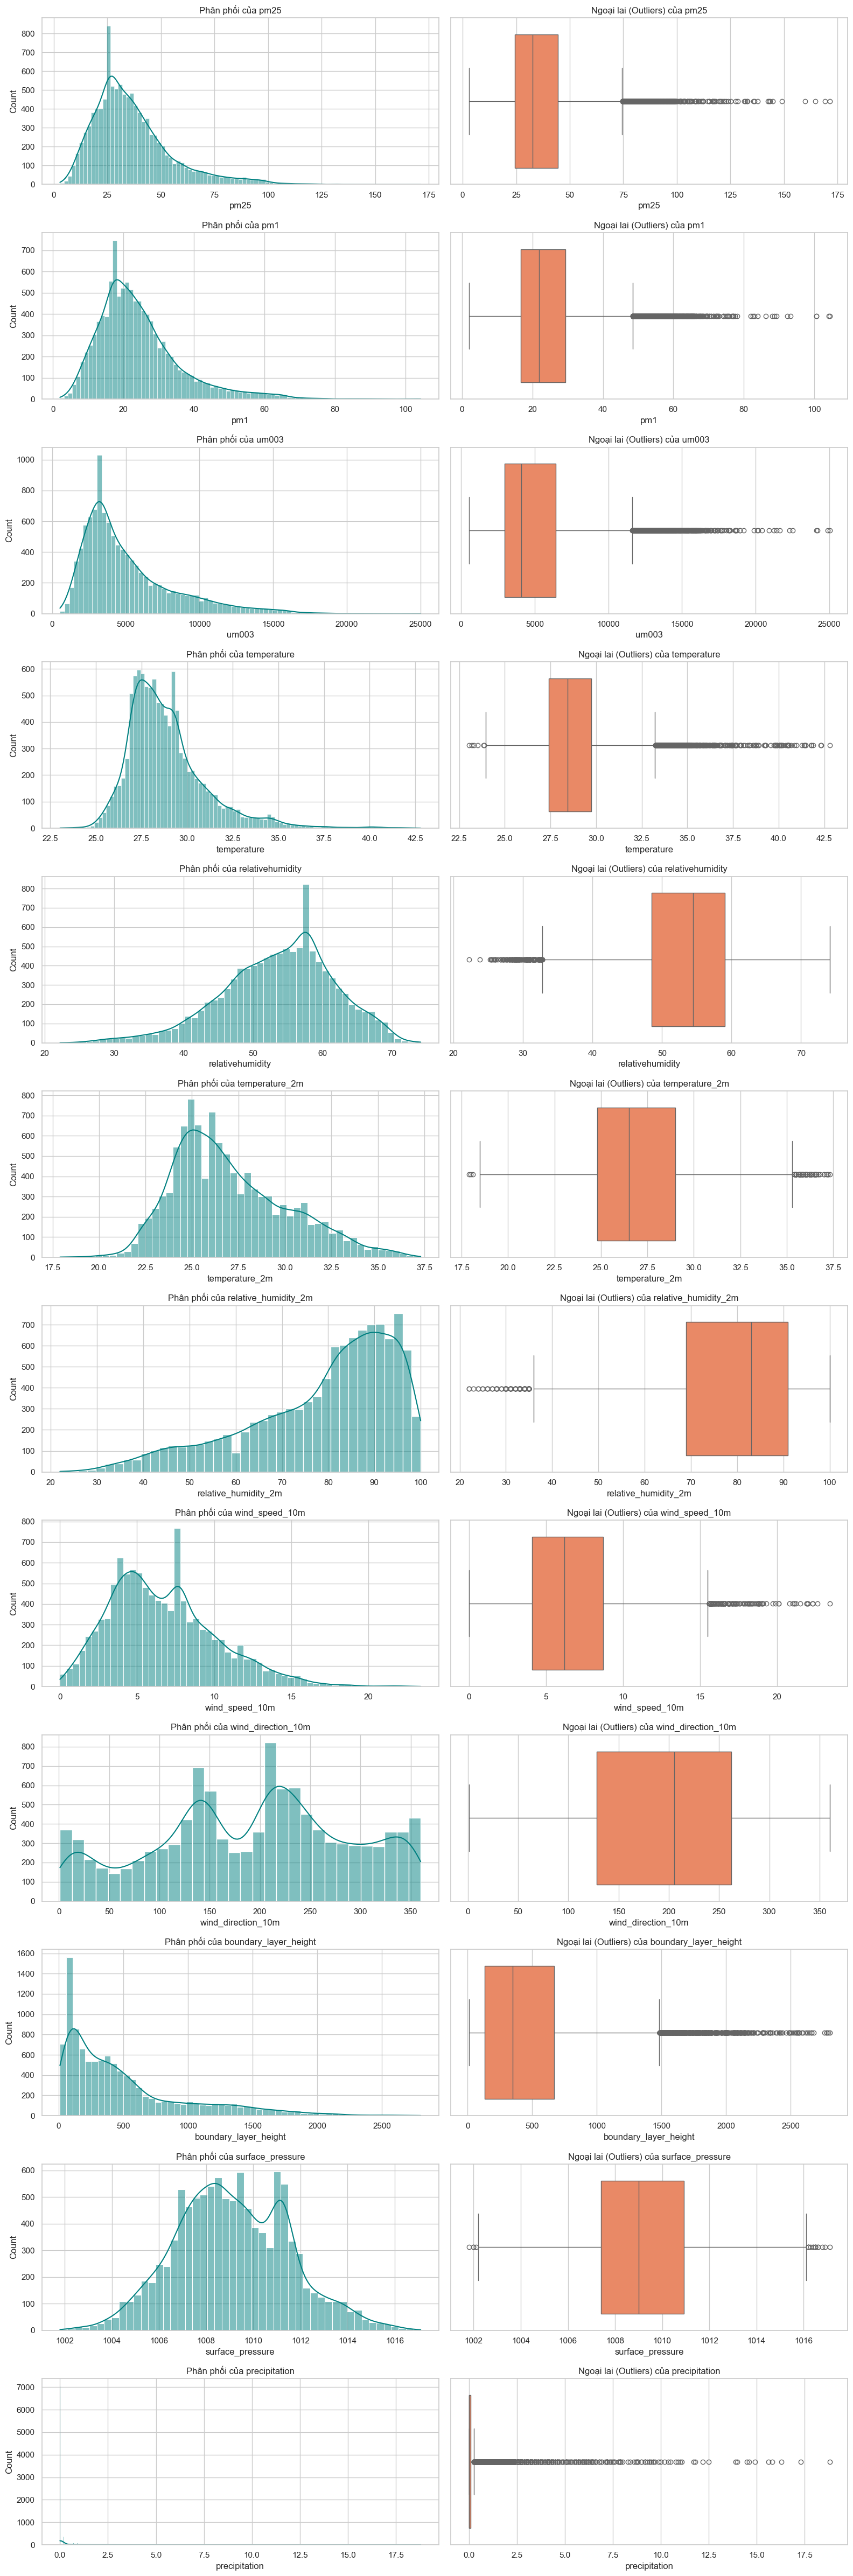

In [8]:
# Danh sách toàn bộ biến 
features_to_check = [
    'pm25', 'pm1', 'um003', 'temperature', 'relativehumidity', 
    'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 
    'wind_direction_10m', 'boundary_layer_height', 'surface_pressure', 'precipitation'
]

# Chỉ lấy những cột thực sự tồn tại trong file csv
valid_features = [f for f in features_to_check if f in df.columns]

fig, axes = plt.subplots(len(valid_features), 2, figsize=(16, 4 * len(valid_features)))

for i, col in enumerate(valid_features):
    # Biểu đồ Histogram & KDE (Xem phân phối để quyết định Scale/Sparse)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Phân phối của {col}')
    
    # Biểu đồ Boxplot (Xem Outliers)
    sns.boxplot(x=df[col], ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Ngoại lai (Outliers) của {col}')

plt.tight_layout()
plt.show()

3. BIVARIATE EDA (Bổ sung Scatter + Regression & Wind Binning)

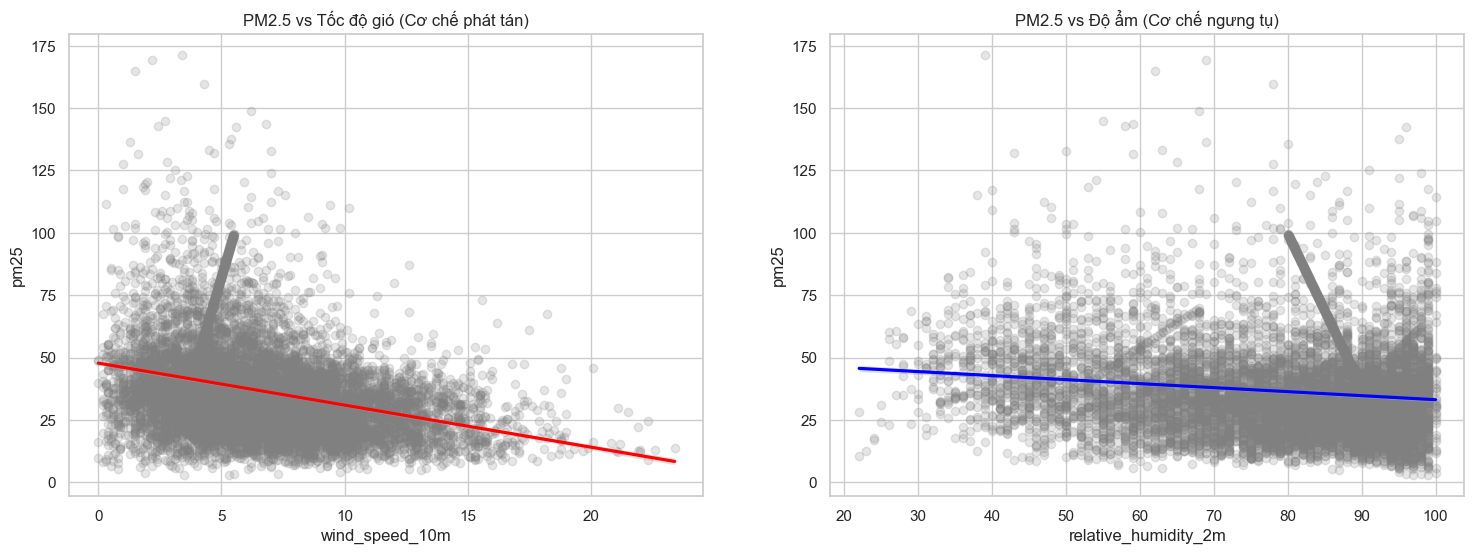


--- Phân tích Hướng gió (Wind Direction Binning) ---


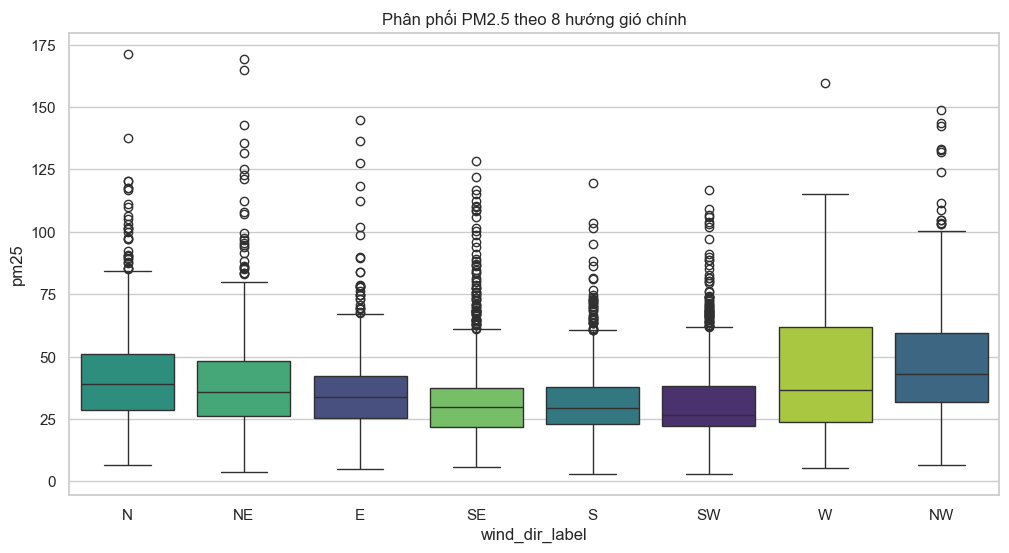

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# PM2.5 vs Wind Speed
sns.regplot(data=df, x='wind_speed_10m', y='pm25', ax=ax1, 
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'red'})
ax1.set_title('PM2.5 vs Tốc độ gió (Cơ chế phát tán)')

# PM2.5 vs Relative Humidity
sns.regplot(data=df, x='relative_humidity_2m', y='pm25', ax=ax2, 
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'blue'})
ax2.set_title('PM2.5 vs Độ ẩm (Cơ chế ngưng tụ)')
plt.show()

print("\n--- Phân tích Hướng gió (Wind Direction Binning) ---")
def wind_dir_to_label(deg):
    if pd.isna(deg): return np.nan
    labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    return labels[int(((deg + 22.5) % 360) / 45)]

df['wind_dir_label'] = df['wind_direction_10m'].apply(wind_dir_to_label)
direction_order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='wind_dir_label', y='pm25', order=direction_order, hue='wind_dir_label', palette='viridis', legend=False)
plt.title('Phân phối PM2.5 theo 8 hướng gió chính')
plt.show()

4. Multivariate EDA (Phân tích đa biến)

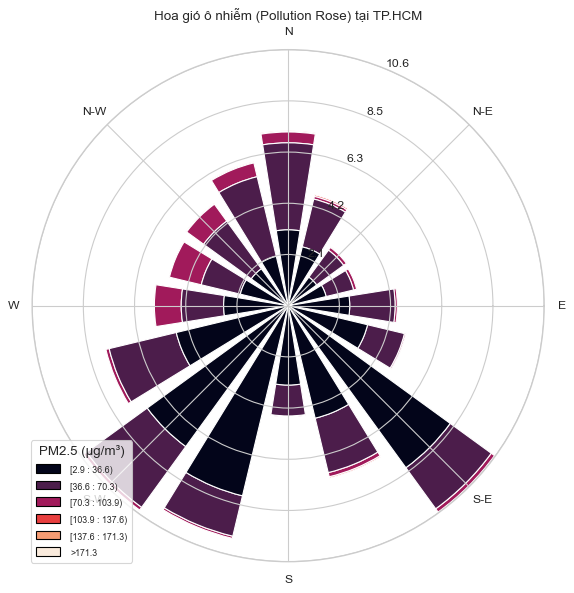


--- Phân tích Autocorrelation Decay (48 Giờ) ---


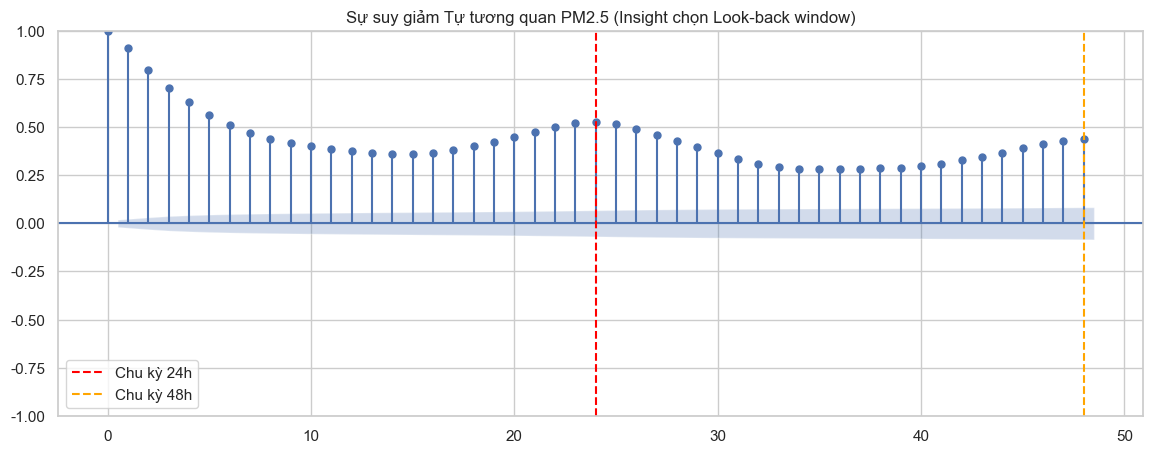

In [10]:
ax = WindroseAxes.from_ax()
ax.bar(df['wind_direction_10m'], df['pm25'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend(title="PM2.5 (µg/m³)")
plt.title("Hoa gió ô nhiễm (Pollution Rose) tại TP.HCM")
plt.show()

print("\n--- Phân tích Autocorrelation Decay (48 Giờ) ---")
# Vẽ lại ACF nhưng nhấn mạnh sự suy giảm trong 48h để chọn Window Size cho LSTM
plt.figure(figsize=(14, 5))
df_resampled = df['pm25'].resample('h').mean().ffill()
plot_acf(df_resampled, lags=48, ax=plt.gca())
plt.axvline(x=24, color='red', linestyle='--', label='Chu kỳ 24h')
plt.axvline(x=48, color='orange', linestyle='--', label='Chu kỳ 48h')
plt.title('Sự suy giảm Tự tương quan PM2.5 (Insight chọn Look-back window)')
plt.legend()
plt.show()

# Giữ lại các phần phân tích cấu trúc thời gian cũ của bạn
df['hour'] = df.index.hour
df['day_name'] = df.index.day_name()

5. CHUỖI THỜI GIAN (Decomposition & ACF/PACF)


--- Phân tích Chuỗi thời gian ---


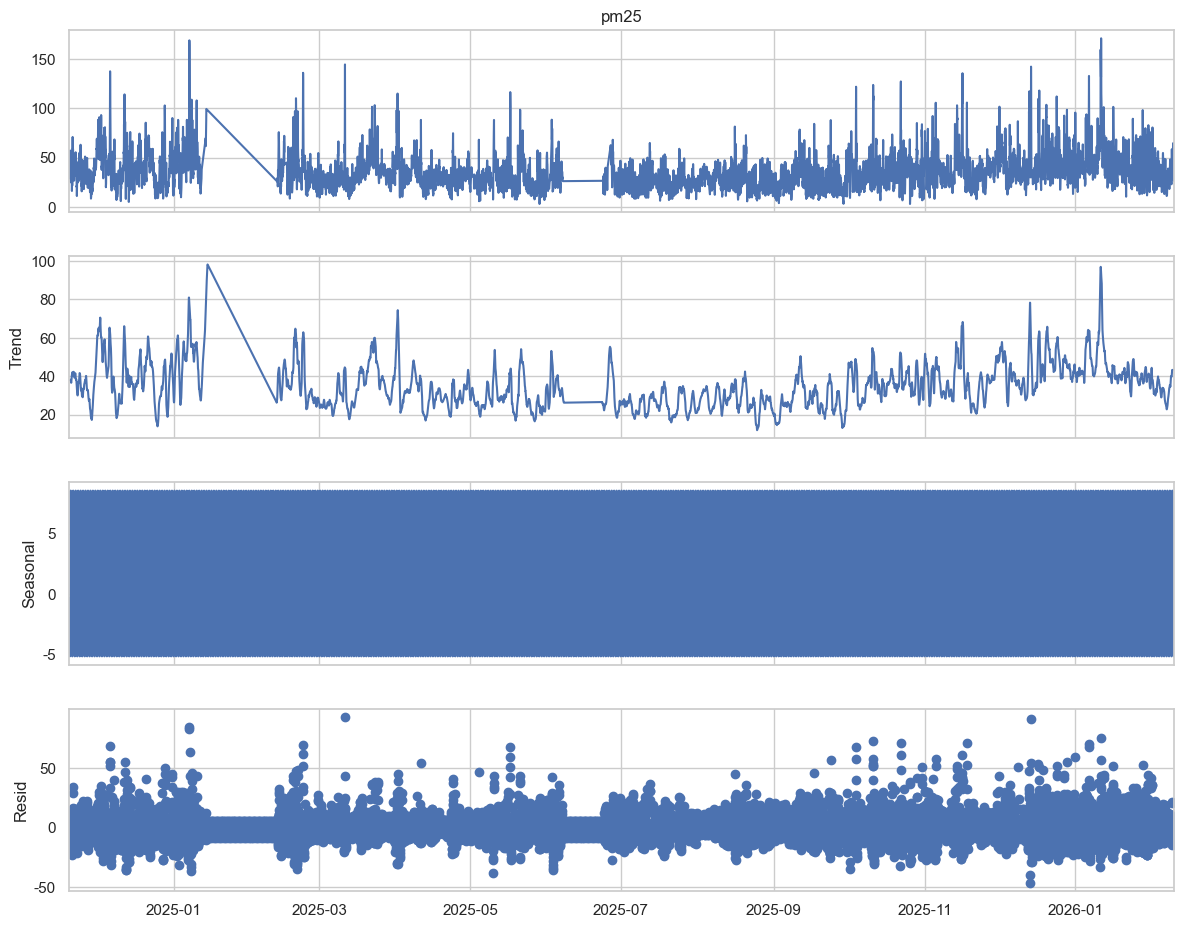

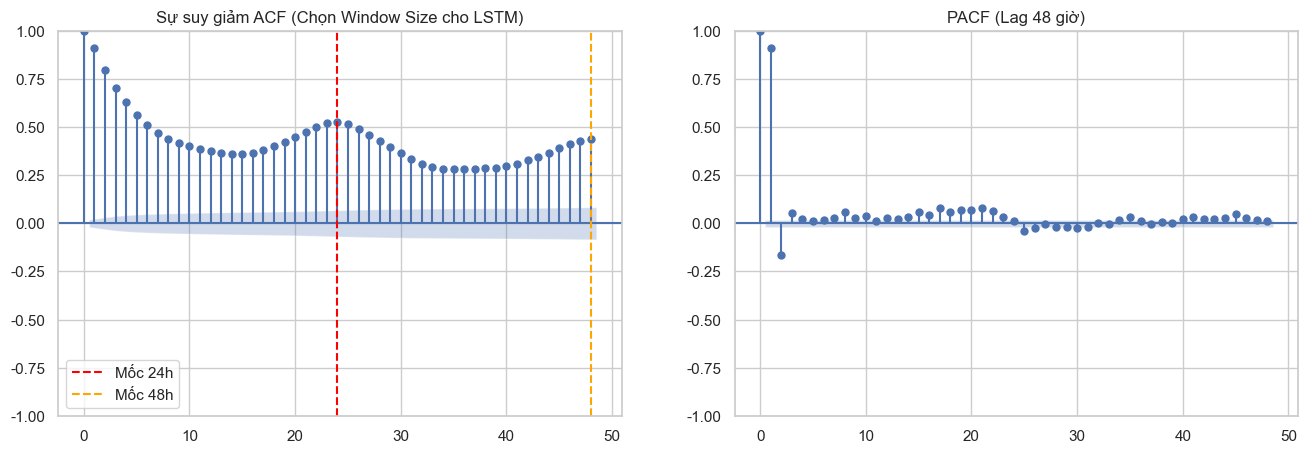

In [11]:
print("\n--- Phân tích Chuỗi thời gian ---")
df_resampled = df['pm25'].resample('h').mean().ffill()

#  Time-series Decomposition
result = seasonal_decompose(df_resampled.dropna(), model='additive', period=24)
fig = result.plot()
fig.set_size_inches(12, 10)
plt.show()

# Autocorrelation Decay (Nhấn mạnh chu kỳ 24h-48h)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_resampled.dropna(), lags=48, ax=ax1)
ax1.axvline(x=24, color='red', linestyle='--', label='Mốc 24h')
ax1.axvline(x=48, color='orange', linestyle='--', label='Mốc 48h')
ax1.set_title('Sự suy giảm ACF (Chọn Window Size cho LSTM)')
ax1.legend()

plot_pacf(df_resampled.dropna(), lags=48, ax=ax2)
ax2.set_title('PACF (Lag 48 giờ)')
plt.show()

6. CLASS BALANCE (AQI)

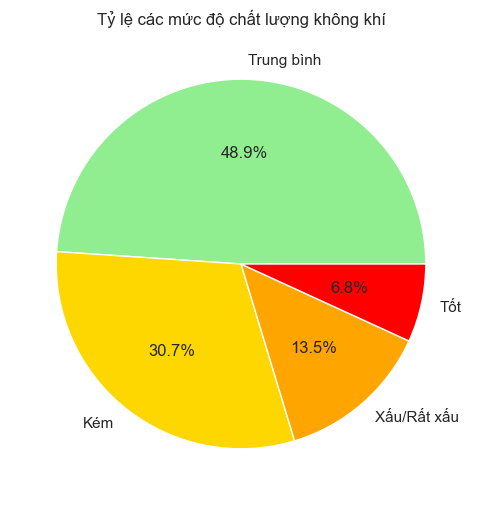

In [12]:
def get_aqi_label(x):
    if x <= 15: return 'Tốt'
    elif x <= 35: return 'Trung bình'
    elif x <= 55: return 'Kém'
    else: return 'Xấu/Rất xấu'

df['aqi_label'] = df['pm25'].apply(get_aqi_label)
plt.figure(figsize=(8, 6))
df['aqi_label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'gold', 'orange', 'red'])
plt.title('Tỷ lệ các mức độ chất lượng không khí')
plt.ylabel('')
plt.show()